In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 6)


In [49]:
data_path = Path("/Users/kierangivens/Downloads/softcite-extractions-oa-data/p05_five_percent_random_subset/")

files = {
    "papers": data_path / "papers.parquet",
    "mentions": data_path / "mentions.pdf.parquet",
    "purpose_assessments": data_path / "purpose_assessments.pdf.parquet",
}

# Check if all files exist
print("Checking files...")
for file in files.values():
    print(f"{file.name}: {'found' if file.exists() else 'missing'}")

if all(file.exists() for file in files.values()):
    print("All files found. Ready to load data.")
else:
    print("Some files are missing. Check the folder path.")


Checking files...
papers.parquet: found
mentions.pdf.parquet: found
purpose_assessments.pdf.parquet: found
All files found. Ready to load data.


In [50]:
print("Loading parquet files")

papers_df = pd.read_parquet(files['papers'], engine="pyarrow")
print(f"Papers dataset: {papers_df.shape[0]:,} rows, {papers_df.shape[1]} columns")

mentions_df = pd.read_parquet(files['mentions'], engine="pyarrow")
print(f"Mentions dataset: {mentions_df.shape[0]:,} rows, {mentions_df.shape[1]} columns")

purpose_df = pd.read_parquet(files['purpose_assessments'], engine="pyarrow")
print(f"Purpose assessments dataset: {purpose_df.shape[0]:,} rows, {purpose_df.shape[1]} columns")

print("\nData loaded successfully")


Loading parquet files
Papers dataset: 320,866 rows, 13 columns
Mentions dataset: 2,777,758 rows, 15 columns
Purpose assessments dataset: 16,666,548 rows, 7 columns

Data loaded successfully


# Look at the initial heads for the dataframes


In [51]:
papers_df.head()

,paper_id,softcite_id,title,published_year,published_date,publication_venue,publisher_name,doi,pmcid,pmid,genre,license_type,has_mentions
0,84,00003a57-7df8-4951-bc85-8b49e7b8d8ad,Scalability and feasibility of photoelectroche...,2015,2015-01-01,Energy &amp; Environmental Science,Royal Society of Chemistry (RSC),10.1039/c5ee02188j,,,journal-article,,True
1,165,00007678-4c96-4f8f-af0b-a9057e609234,Early prediction of paratuberculosis health st...,2022,2022-08-12,,Research Square Platform LLC,10.21203/rs.3.rs-1929091/v1,,,posted-content,,True
2,196,00008d79-abca-4c1b-a995-d7452bd804de,A Comparison of DNA Pools Constructed Followin...,2005,2005-08-01,Twin Research and Human Genetics,Cambridge University Press (CUP),10.1375/1832427054936718,,,journal-article,,True
3,294,0000d6e5-ae77-4518-9a28-0560b77401aa,DicomBrowser: Software for Viewing and Modifyi...,2012,2012-02-15,Journal of Digital Imaging,Springer Science and Business Media LLC,10.1007/s10278-012-9462-x,PMC3447088,22349992,journal-article,,True
4,313,0000e448-bd17-4865-913b-9ee4e483edd4,Validation of the Arabic version of the SCOFF ...,2015,2015-05-01,Eastern Mediterranean Health Journal,World Health Organization Regional Office for ...,10.26719/2015.21.5.326,,26343121,journal-article,,True


In [52]:
mentions_df.head()

,software_mention_id,paper_id,source_file_type,mention_index,software_raw,software_normalized,version_raw,version_normalized,publisher_raw,publisher_normalized,language_raw,language_normalized,url_raw,url_normalized,context_full_text
0,84.pdf.00000,84,pdf,0,ImageJ,ImageJ,,,,,,,,,The size of the nanoparticles on the pictures ...
1,84.pdf.00001,84,pdf,1,EC Lab,EC Lab,,,,,,,,,"For the photoelectrochemical measurements, a B..."
2,165.pdf.00000,165,pdf,0,MagMET,MagMET,,,,,,,,,MagMET allows for qualitative and quantitative...
3,165.pdf.00001,165,pdf,1,AVAILABILITY STATEMENT,AVAILABILITY STATEMENT,,,,,,,,,SOFTWARE OR DATABASE AVAILABILITY STATEMENT T...
4,165.pdf.00002,165,pdf,2,Metaboanalyst,Metaboanalyst,,,,,,,www.metaboanalyst.ca,www.metaboanalyst.ca,Since the pathway analysis on the Metaboanalys...


In [53]:
purpose_df.head(40)

,software_mention_id,paper_id,source_file_type,mention_index,scope,purpose,certainty_score
0,84.pdf.00000,84,pdf,0,document,created,6.556511e-06
1,84.pdf.00000,84,pdf,0,document,shared,1.192093e-07
2,84.pdf.00000,84,pdf,0,document,used,9.999969e-01
3,84.pdf.00000,84,pdf,0,local,created,6.556511e-06
4,84.pdf.00000,84,pdf,0,local,shared,1.192093e-07
5,84.pdf.00000,84,pdf,0,local,used,9.999969e-01
6,84.pdf.00001,84,pdf,1,document,created,4.541874e-05
7,84.pdf.00001,84,pdf,1,document,shared,1.192093e-07
8,84.pdf.00001,84,pdf,1,document,used,9.999943e-01
9,84.pdf.00001,84,pdf,1,local,created,4.541874e-05


## Section 2: Dataset Overview

Schema, data types, descriptive statistics, and checking for missing values for each table

In [54]:
print("PAPERS TABLE")
papers_df.info()
print()
papers_df.describe(include="all")

PAPERS TABLE
<class 'pandas.DataFrame'>
RangeIndex: 320866 entries, 0 to 320865
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   paper_id           320866 non-null  uint32
 1   softcite_id        320866 non-null  str   
 2   title              320866 non-null  str   
 3   published_year     320866 non-null  uint16
 4   published_date     320866 non-null  object
 5   publication_venue  320866 non-null  str   
 6   publisher_name     320866 non-null  str   
 7   doi                320866 non-null  str   
 8   pmcid              320866 non-null  str   
 9   pmid               320866 non-null  str   
 10  genre              320866 non-null  str   
 11  license_type       320866 non-null  str   
 12  has_mentions       320866 non-null  bool  
dtypes: bool(1), object(1), str(9), uint16(1), uint32(1)
memory usage: 101.1+ MB



,paper_id,softcite_id,title,published_year,published_date,publication_venue,publisher_name,doi,pmcid,pmid,genre,license_type,has_mentions
count,3.208660e+05,320866,320866,320866.000000,320866,320866,320866,320866,320866,320866,320866,320866,320866
unique,NaN,320866,318558,NaN,8784,45527,9586,320866,113126,144087,29,9,1
top,NaN,00003a57-7df8-4951-bc85-8b49e7b8d8ad,,NaN,1970-01-01,,Springer Science and Business Media LLC,10.1039/c5ee02188j,,,journal-article,,True
freq,NaN,1,1118,NaN,6682,34926,36781,1,207726,176762,261299,240375,320866
mean,1.187695e+07,NaN,NaN,1975.052467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,6.859927e+06,NaN,NaN,285.311313,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,8.400000e+01,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,5.929754e+06,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.189220e+07,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.782157e+07,NaN,NaN,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
print("MENTIONS TABLE")
mentions_df.info()
print()
mentions_df.describe(include="all")

MENTIONS TABLE
<class 'pandas.DataFrame'>
RangeIndex: 2777758 entries, 0 to 2777757
Data columns (total 15 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   software_mention_id   str   
 1   paper_id              uint32
 2   source_file_type      str   
 3   mention_index         uint16
 4   software_raw          str   
 5   software_normalized   str   
 6   version_raw           str   
 7   version_normalized    str   
 8   publisher_raw         str   
 9   publisher_normalized  str   
 10  language_raw          str   
 11  language_normalized   str   
 12  url_raw               str   
 13  url_normalized        str   
 14  context_full_text     str   
dtypes: str(13), uint16(1), uint32(1)
memory usage: 860.4 MB



,software_mention_id,paper_id,source_file_type,mention_index,software_raw,software_normalized,version_raw,version_normalized,publisher_raw,publisher_normalized,language_raw,language_normalized,url_raw,url_normalized,context_full_text
count,2777758,2.777758e+06,2777758,2.777758e+06,2777758,2777758,2777758,2777758,2777758,2777758,2777758,2777758,2777758,2777758,2777758
unique,2777758,NaN,1,NaN,234137,221434,19461,18744,28538,25062,184,179,21782,21484,2123899
top,84.pdf.00000,NaN,pdf,NaN,LaTeX,LaTeX,,,,,,,,,An error in the conversion from LaTeX to XML h...
freq,1,NaN,2777758,NaN,117252,117252,2220254,2220254,2457319,2457319,2713359,2713359,2679639,2679639,35023
mean,NaN,1.179244e+07,NaN,2.352688e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,6.804224e+06,NaN,1.990968e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,8.400000e+01,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,5.994680e+06,NaN,2.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,1.164916e+07,NaN,1.200000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,1.764336e+07,NaN,4.300000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
print("PURPOSE ASSESSMENTS TABLE")
purpose_df.info()
print()
purpose_df.describe(include="all")

PURPOSE ASSESSMENTS TABLE
<class 'pandas.DataFrame'>
RangeIndex: 16666548 entries, 0 to 16666547
Data columns (total 7 columns):
 #   Column               Dtype  
---  ------               -----  
 0   software_mention_id  str    
 1   paper_id             uint32 
 2   source_file_type     str    
 3   mention_index        uint16 
 4   scope                str    
 5   purpose              str    
 6   certainty_score      float64
dtypes: float64(1), str(4), uint16(1), uint32(1)
memory usage: 1.3 GB



,software_mention_id,paper_id,source_file_type,mention_index,scope,purpose,certainty_score
count,16666548,1.666655e+07,16666548,1.666655e+07,16666548,16666548,1.666655e+07
unique,2777758,NaN,1,NaN,2,3,NaN
top,84.pdf.00000,NaN,pdf,NaN,document,created,NaN
freq,6,NaN,16666548,NaN,8333274,5555516,NaN
mean,NaN,1.179244e+07,NaN,2.352688e+02,NaN,NaN,3.281964e-01
std,NaN,6.804223e+06,NaN,1.990968e+03,NaN,NaN,4.530572e-01
min,NaN,8.400000e+01,NaN,0.000000e+00,NaN,NaN,1.192093e-07
25%,NaN,5.994680e+06,NaN,2.000000e+00,NaN,NaN,1.788139e-06
50%,NaN,1.164916e+07,NaN,1.200000e+01,NaN,NaN,2.143979e-04
75%,NaN,1.764336e+07,NaN,4.300000e+01,NaN,NaN,9.945893e-01


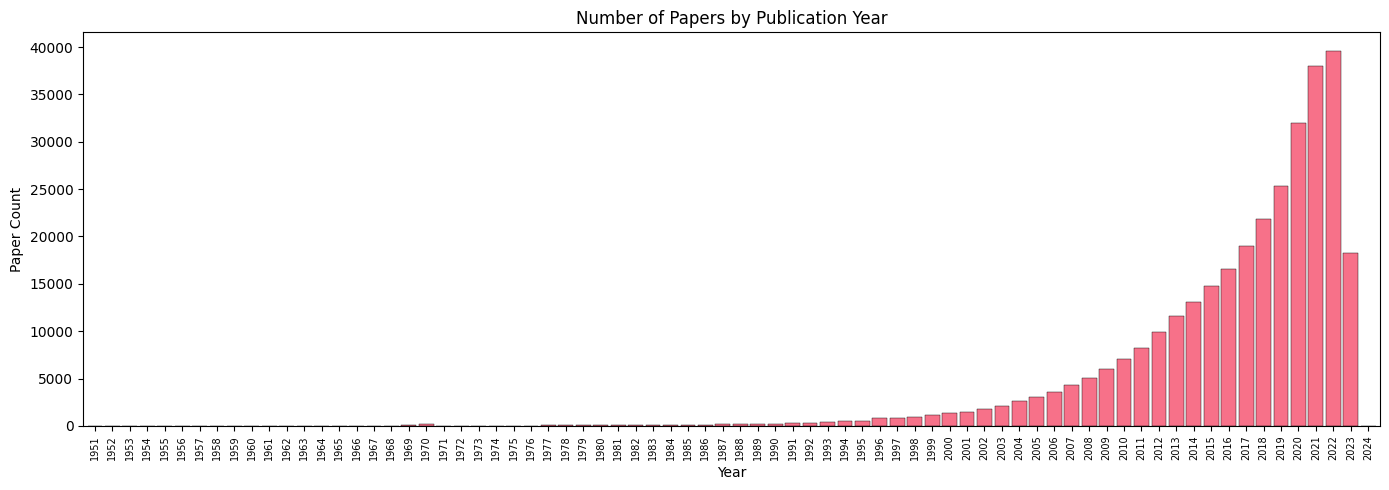

Year range: 1951 – 2024
Median year: 2018
Papers with missing year: 0


In [57]:
fig, ax = plt.subplots(figsize=(14, 5))
year_counts = papers_df['published_year'].dropna().astype(int)
year_counts = year_counts[(year_counts >= 1950) & (year_counts <= 2025)]
year_counts.value_counts().sort_index().plot(kind='bar', ax=ax, width=0.85, edgecolor='black', linewidth=0.3)
ax.set_title("Number of Papers by Publication Year")
ax.set_xlabel("Year")
ax.set_ylabel("Paper Count")
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

print(f"Year range: {year_counts.min()} – {year_counts.max()}")
print(f"Median year: {int(year_counts.median())}")
print(f"Papers with missing year: {papers_df['published_year'].isna().sum():,}")

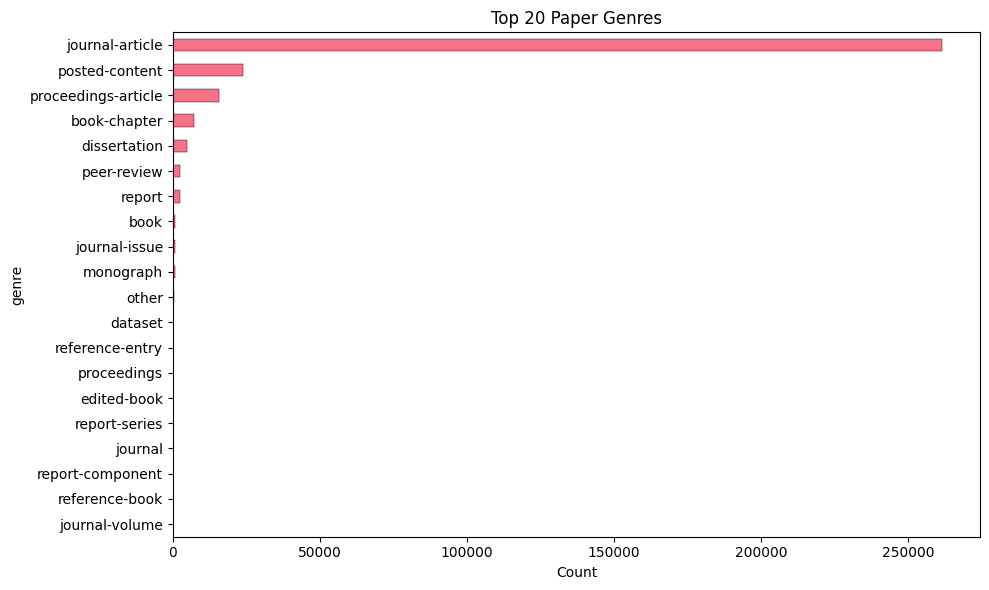

In [58]:
fig, ax = plt.subplots(figsize=(10, 6))
papers_df['genre'].value_counts().head(20).plot(
    kind='barh', ax=ax, edgecolor='black', linewidth=0.3
)
ax.set_title("Top 20 Paper Genres")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

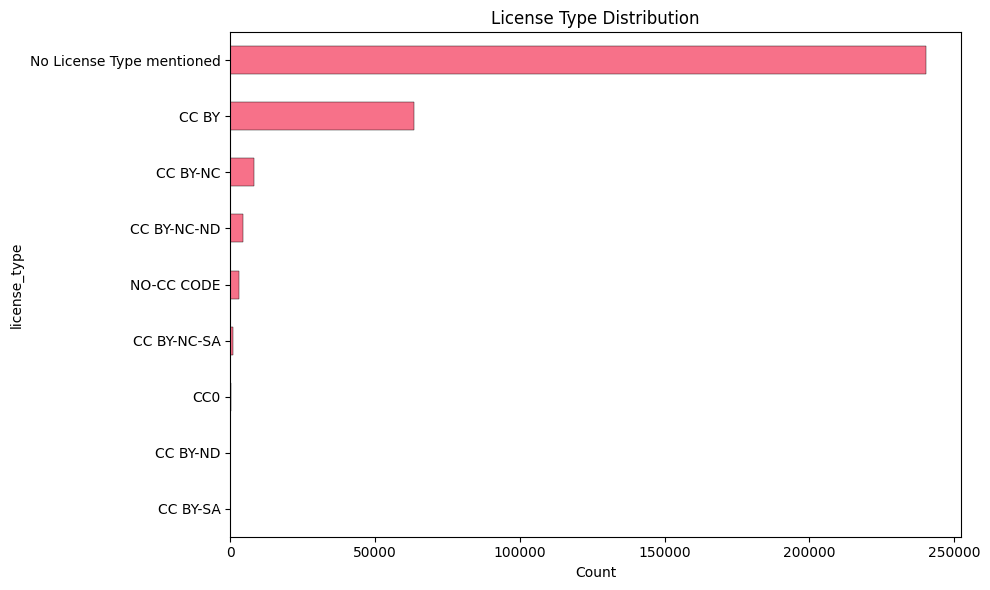

In [59]:
# Fill missing license types with "No License Type mentioned"
papers_df['license_type'] = (
    papers_df['license_type']
    .replace(r'^\s*$', pd.NA, regex=True)
    .fillna("No License Type mentioned")
)

fig, ax = plt.subplots(figsize=(10, 6))
papers_df['license_type'].value_counts().plot(
    kind='barh', ax=ax, edgecolor='black', linewidth=0.3)
ax.set_title("License Type Distribution")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

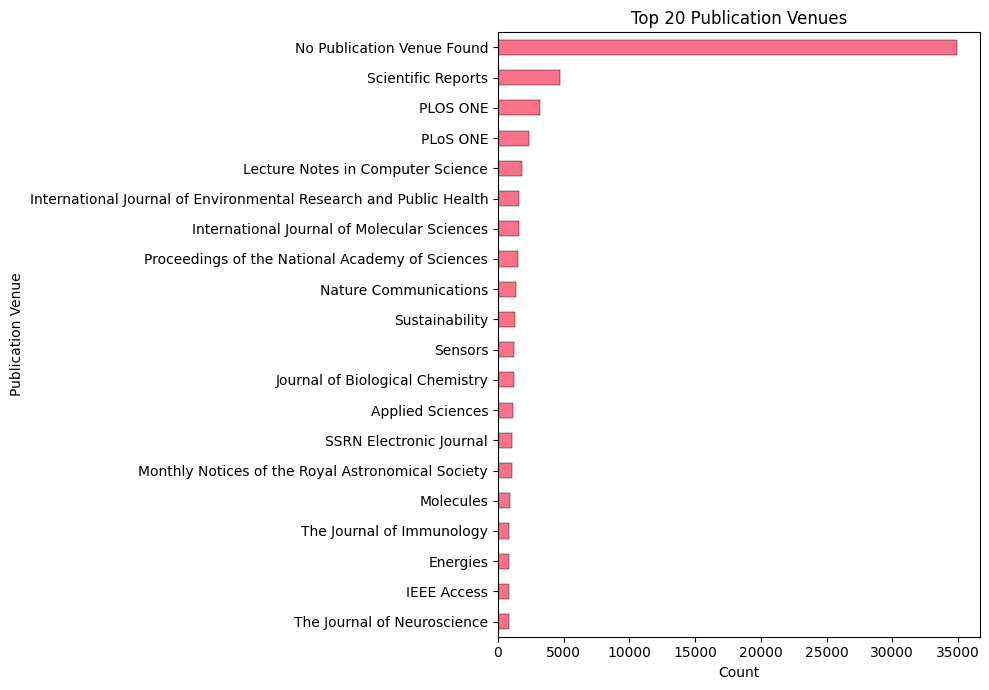

Unique venues: 45,527
Papers labeled 'No Publication Venue Found': 34,926


,publication_venue,count,percentage
0,No Publication Venue Found,34926,10.88
1,Scientific Reports,4686,1.46
2,PLOS ONE,3171,0.99
3,PLoS ONE,2353,0.73
4,Lecture Notes in Computer Science,1866,0.58
5,International Journal of Environmental Researc...,1622,0.51
6,International Journal of Molecular Sciences,1593,0.50
7,Proceedings of the National Academy of Sciences,1502,0.47
8,Nature Communications,1372,0.43
9,Sustainability,1333,0.42


In [60]:
venue_series = (
    papers_df['publication_venue']
    .replace(r'^\s*$', pd.NA, regex=True)
    .fillna("No Publication Venue Found")
)

top_venues = venue_series.value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_venues.plot(kind='barh', ax=ax, edgecolor='black', linewidth=0.3)
ax.set_title("Top 20 Publication Venues")
ax.set_xlabel("Count")
ax.set_ylabel("Publication Venue")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

top_venues_table = (
    top_venues
    .rename_axis("publication_venue")
    .reset_index(name="count")
    .assign(percentage=lambda d: (d["count"] / len(papers_df) * 100).round(2))
)

print(f"Unique venues: {venue_series.nunique():,}")
print(f"Papers labeled 'No Publication Venue Found': "
      f"{(venue_series == 'No Publication Venue Found').sum():,}")

top_venues_table

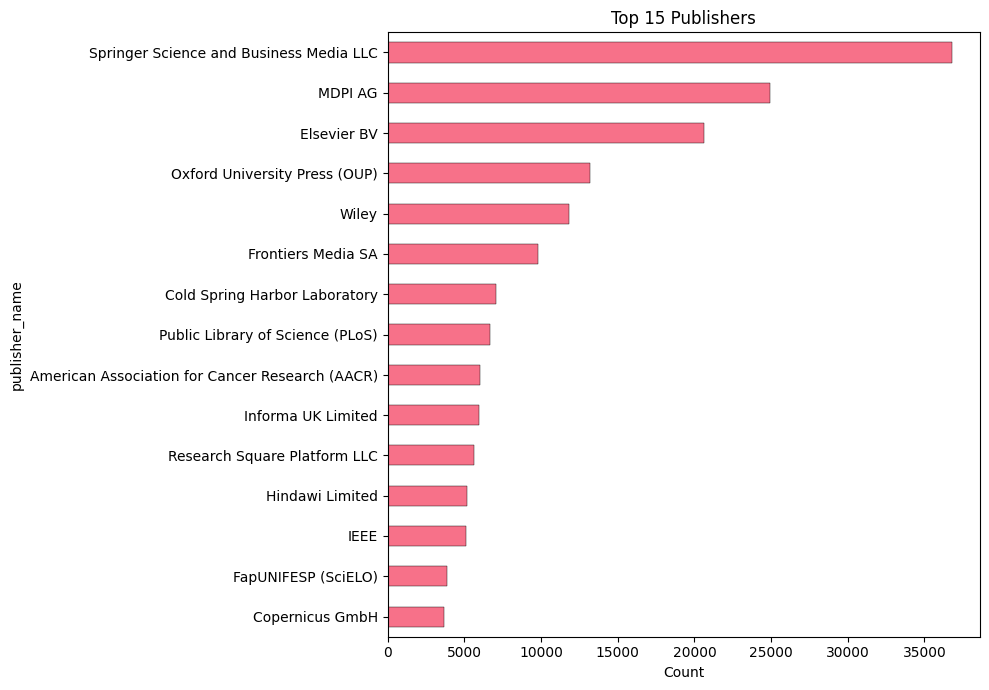

Unique publishers: 9,586
Papers where no publisher is found: 66


,publisher_name,count,share
0,Springer Science and Business Media LLC,36781,11.46
1,MDPI AG,24928,7.77
2,Elsevier BV,20640,6.43
3,Oxford University Press (OUP),13173,4.11
4,Wiley,11836,3.69
5,Frontiers Media SA,9790,3.05
6,Cold Spring Harbor Laboratory,7064,2.20
7,Public Library of Science (PLoS),6664,2.08
8,American Association for Cancer Research (AACR),5992,1.87
9,Informa UK Limited,5958,1.86


In [61]:
publisher_series = (
    papers_df['publisher_name']
    .replace(r'^\s*$', pd.NA, regex=True)
    .fillna("No Publisher Found")
)

top_publishers = publisher_series.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7))
top_publishers.plot(kind='barh', ax=ax, edgecolor='black', linewidth=0.3)
ax.set_title("Top 15 Publishers")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

top_publishers_table = (
    top_publishers
    .rename_axis("publisher_name")
    .reset_index(name="count")
    .assign(share=lambda d: (d["count"] / len(papers_df) * 100).round(2))
)

print(f"Unique publishers: {publisher_series.nunique():,}")
print(f"Papers where no publisher is found: "
      f"{(publisher_series == 'No Publisher Found').sum():,}")

top_publishers_table

In [63]:
unique_software_mentions = mentions_df['software_normalized'].value_counts()
unique_software_mentions.head(20)

software_normalized
LaTeX              117252
SPSS                81880
MATLAB              31567
SAS                 25238
ImageJ              24401
code                23140
GraphPad Prism      21401
Excel               21265
Matlab              17829
script              13971
Android             12403
Google              12155
BLAST               11983
survival            11681
Stata               11449
Linux               11369
scripts              9286
SPSS Statistics      7177
ArcGIS               7059
Google Scholar       6807
Name: count, dtype: int64

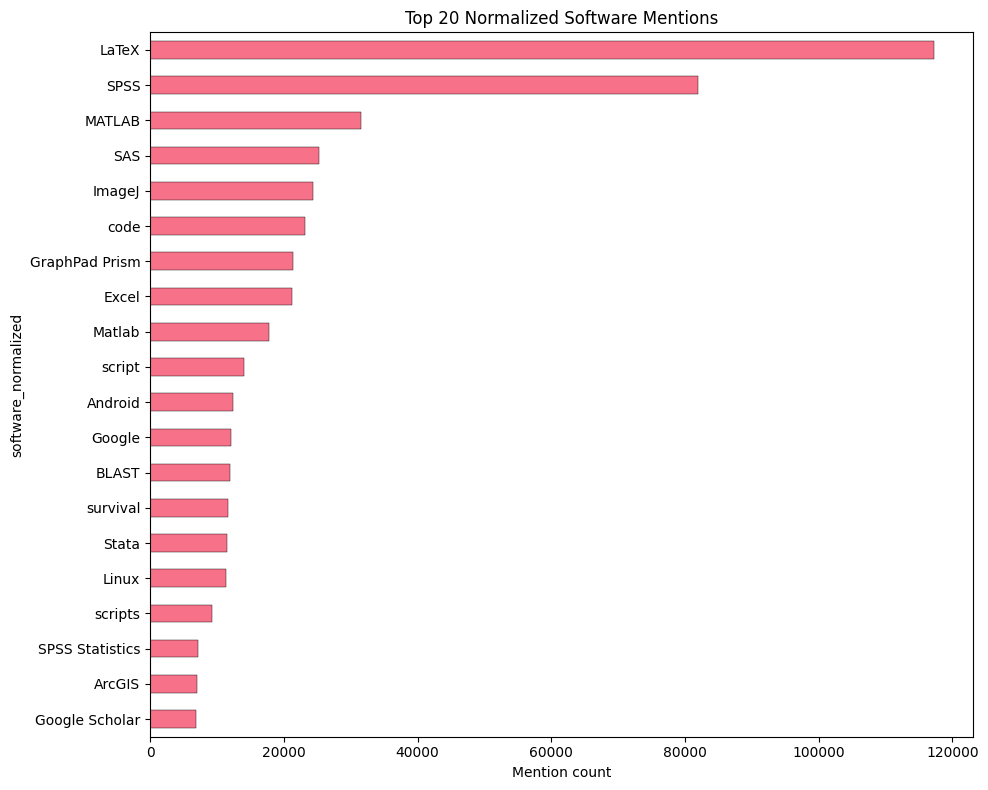

In [66]:
counts = mentions_df['software_normalized'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(10, 8))
counts.plot(kind="barh", ax=ax, edgecolor="black", linewidth=0.3)
ax.set_title(f"Top {20} Normalized Software Mentions")
ax.set_xlabel("Mention count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [68]:
# Count mentions per paper
mentions_per_paper = mentions_df.groupby('paper_id').size().reset_index(name='mention_count')

# Show distribution of mentions per paper
print(f"\nMention count statistics:")
print(mentions_per_paper['mention_count'].describe())

# Show papers with most mentions
print(f"\nTop 20 papers by mention count:")
top_papers = mentions_per_paper.nlargest(20, 'mention_count')
print(top_papers)



Mention count statistics:
count    320866.000000
mean          8.657066
std          63.302443
min           1.000000
25%           1.000000
50%           2.000000
75%           6.000000
max       32162.000000
Name: mention_count, dtype: float64

Top 20 papers by mention count:
        paper_id  mention_count
125535   9286192          32162
128204   9485442           3585
274699  20323662           3148
146310  10830805           3063
297591  22031951           2690
34786    2567414           2417
292229  21627864           1619
74901    5535986           1616
290172  21472294           1575
21163    1564995           1343
222235  16462385           1271
29175    2146144           1270
137177  10160346           1260
209129  15488848           1248
72495    5354066           1197
166532  12345743           1177
70795    5229009           1155
227367  16837963           1118
105729   7821710           1057
486        36181           1034


In [ ]:
def plot_software_mentions_for_paper(paper_id, top_n=10, figsize=(12, 6), color='skyblue'):
    """
    Create a bar chart showing the top software mentions for a specific paper.
    
    Parameters:
    -----------
    paper_id : int
        The paper ID to analyze
    top_n : int, default 10
        Number of top software to display
    figsize : tuple, default (12, 6)
        Figure size for the plot
    color : str, default 'skyblue'
        Color for the bars
    
    Returns:
    --------
    matplotlib.figure.Figure
        The created figure object
    """
    # Get the paper info
    paper_info = papers_df[papers_df['paper_id'] == paper_id]
    if len(paper_info) == 0:
        print(f"No paper found with ID {paper_id}")
        return None
    
    # Get software mentions for this paper
    paper_mentions = mentions_df[mentions_df['paper_id'] == paper_id]
    if len(paper_mentions) == 0:
        print(f"No software mentions found for paper {paper_id}")
        return None
    
    # Count mentions by software
    mention_counts = paper_mentions['software_normalized'].value_counts()
    
    # Get top N software
    top_n_mentions = mention_counts.head(top_n)
    
    # Convert to DataFrame for plotting
    plot_df = top_n_mentions.reset_index()
    plot_df.columns = ['Software', 'Mentions']
    
    # Create the plot
    plt.figure(figsize=figsize)
    bars = plt.bar(plot_df['Software'], plot_df['Mentions'], color=color)
    
    # Add labels and title
    paper_title = paper_info['title'].iloc[0] if 'title' in paper_info.columns else f"Paper {paper_id}"
    paper_title = str(paper_title).replace('$', r'\$')
    plt.title(f'Top Software Mentions found in {paper_title} ({paper_info["published_year"].iloc[0]})') 
    plt.xlabel('Software Name')
    plt.ylabel('Number of Mentions')
    
    # Rotate x-axis labels
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels on bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, 
                 int(yval), ha='center', va='bottom', fontsize=10)
    
    # Add grid and adjust layout
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

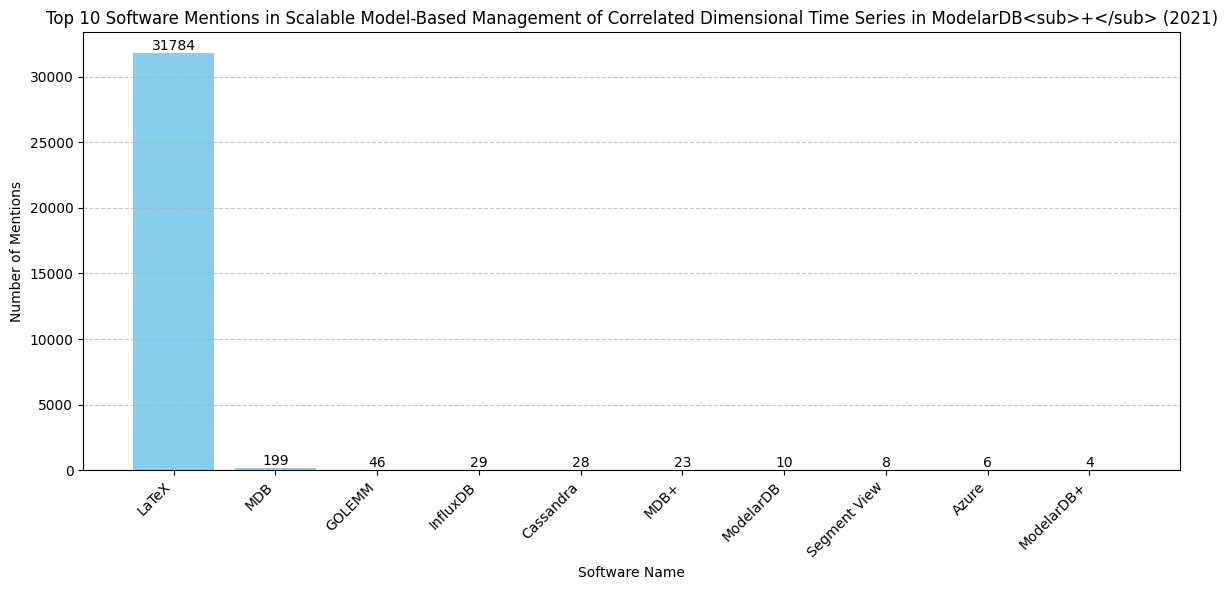

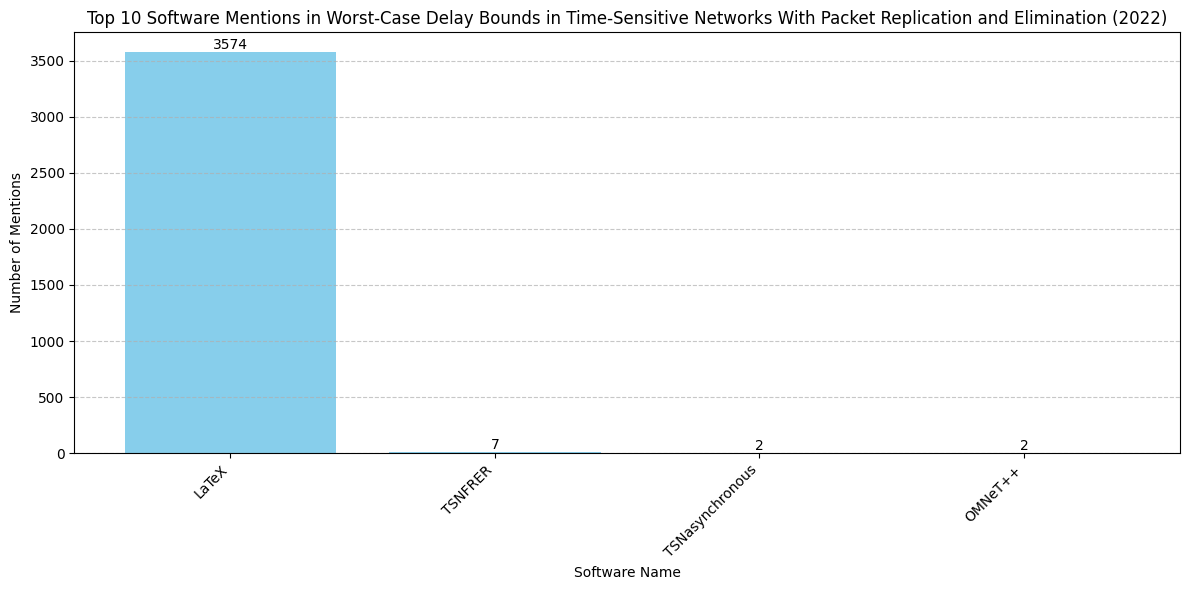

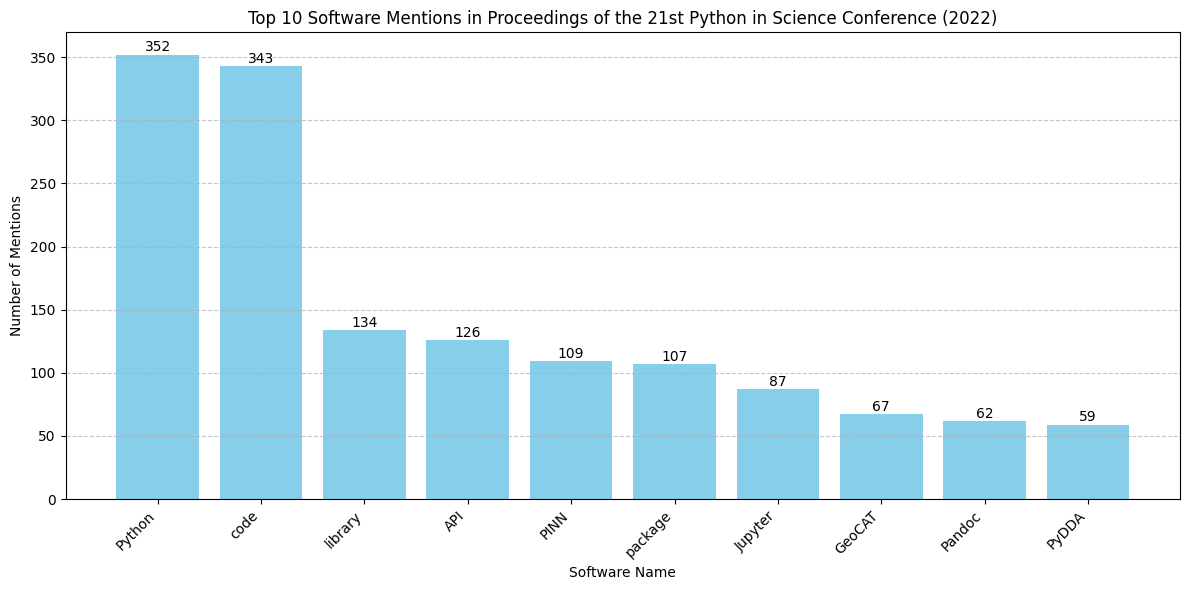

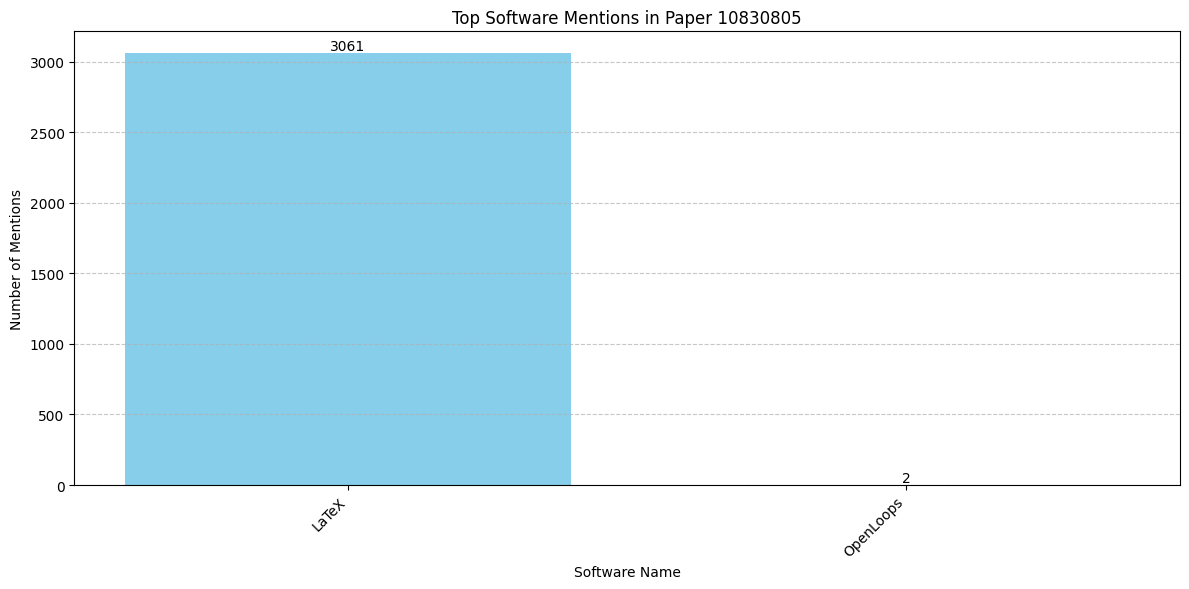

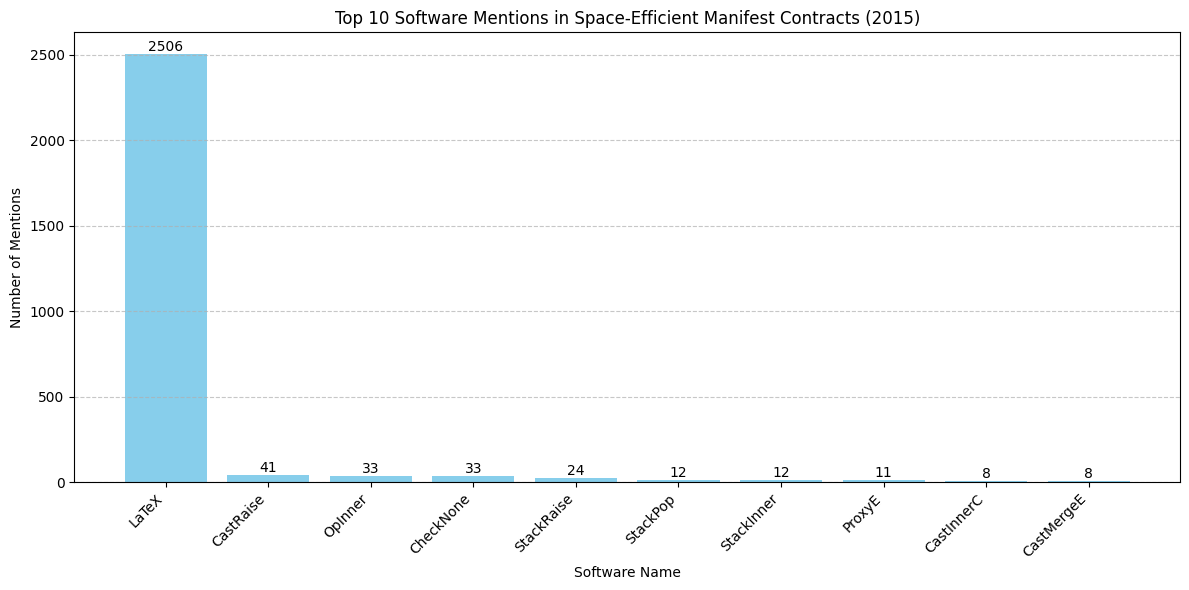

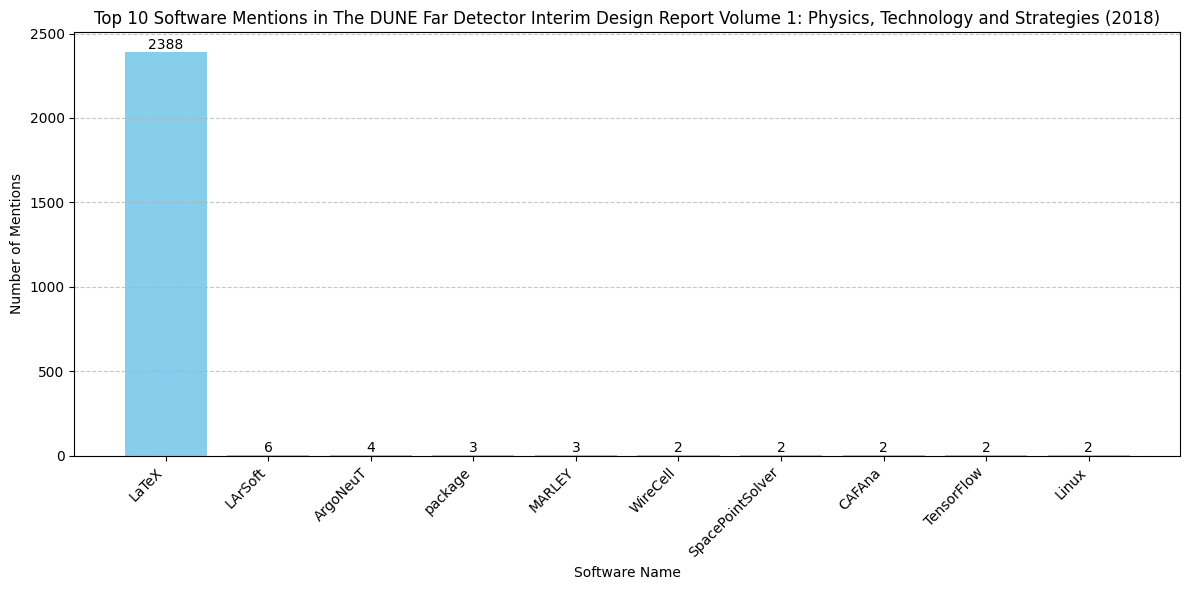

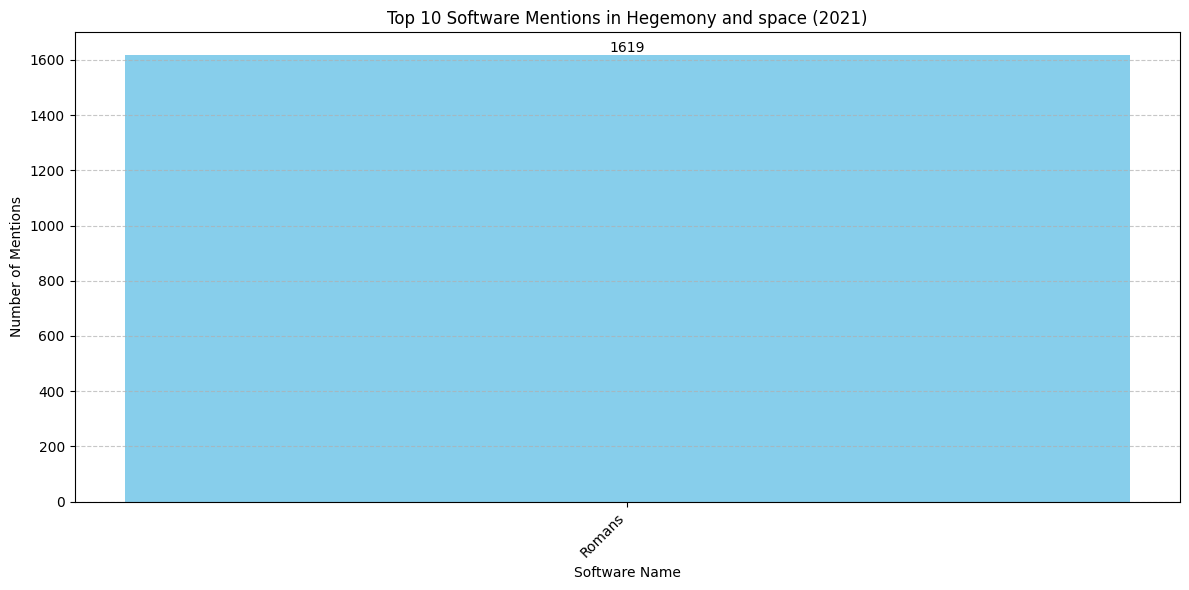

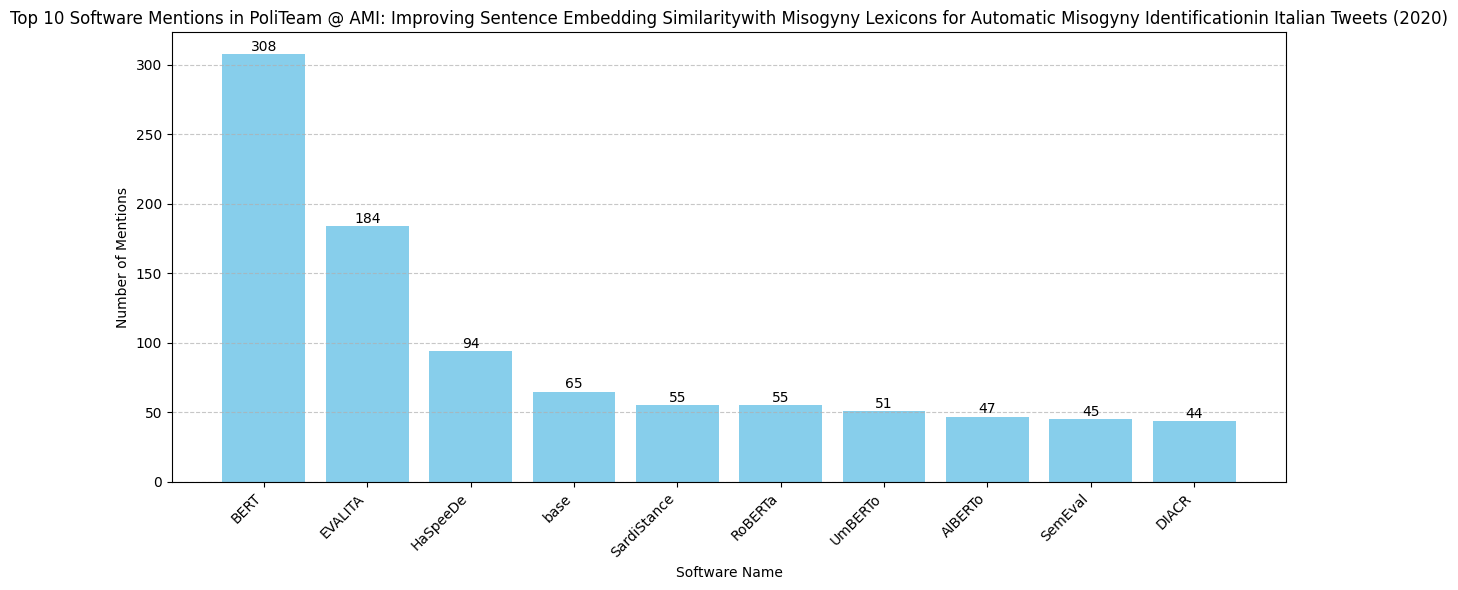

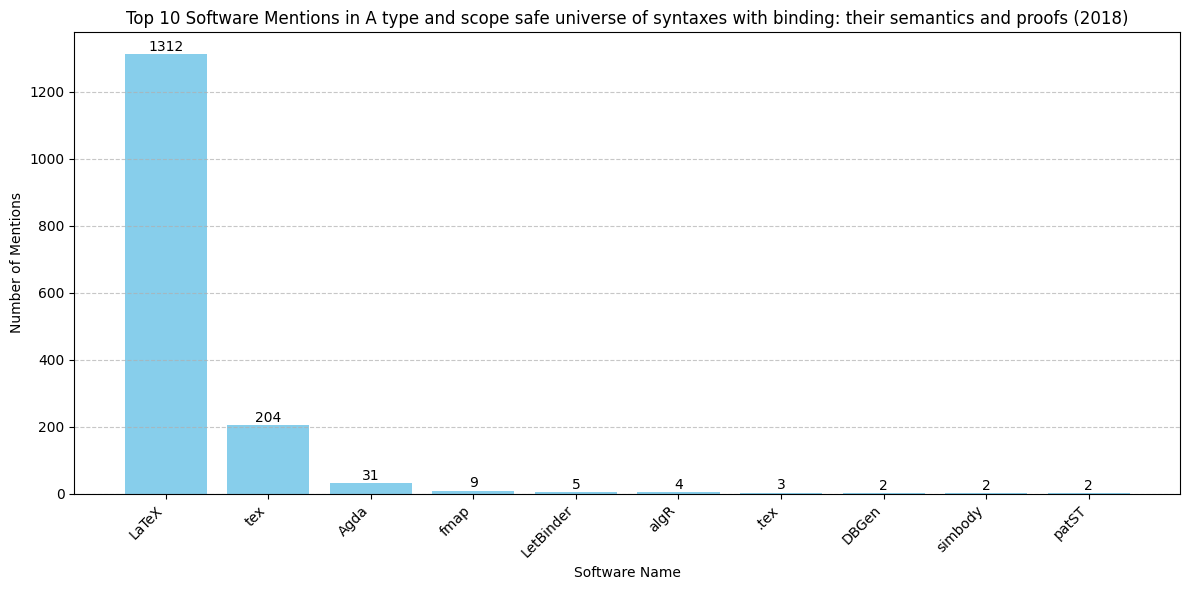

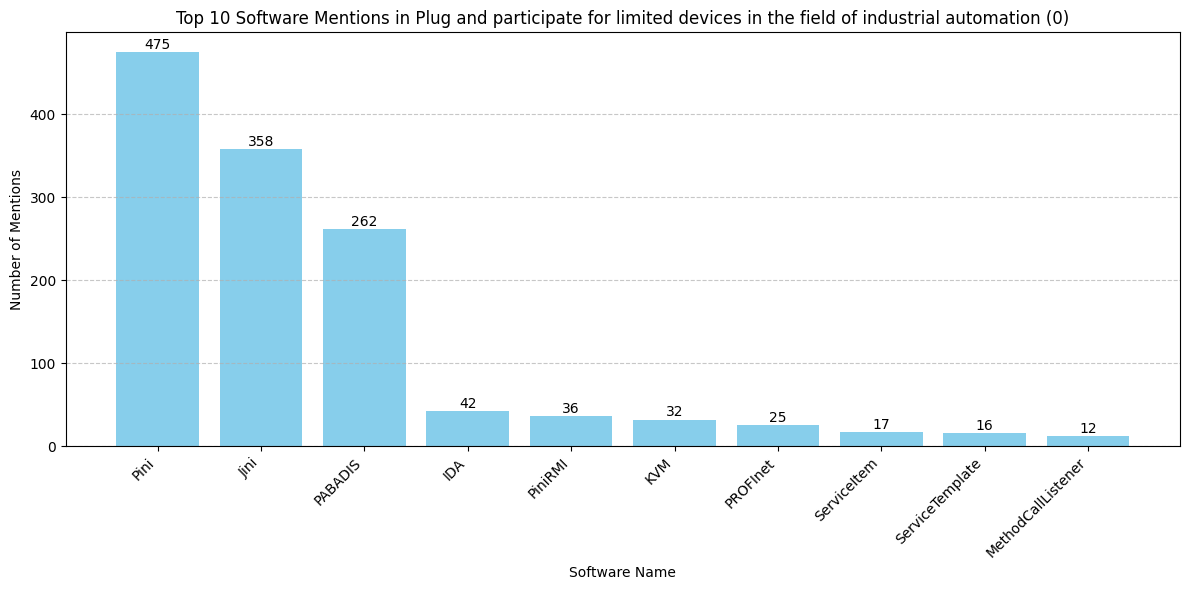

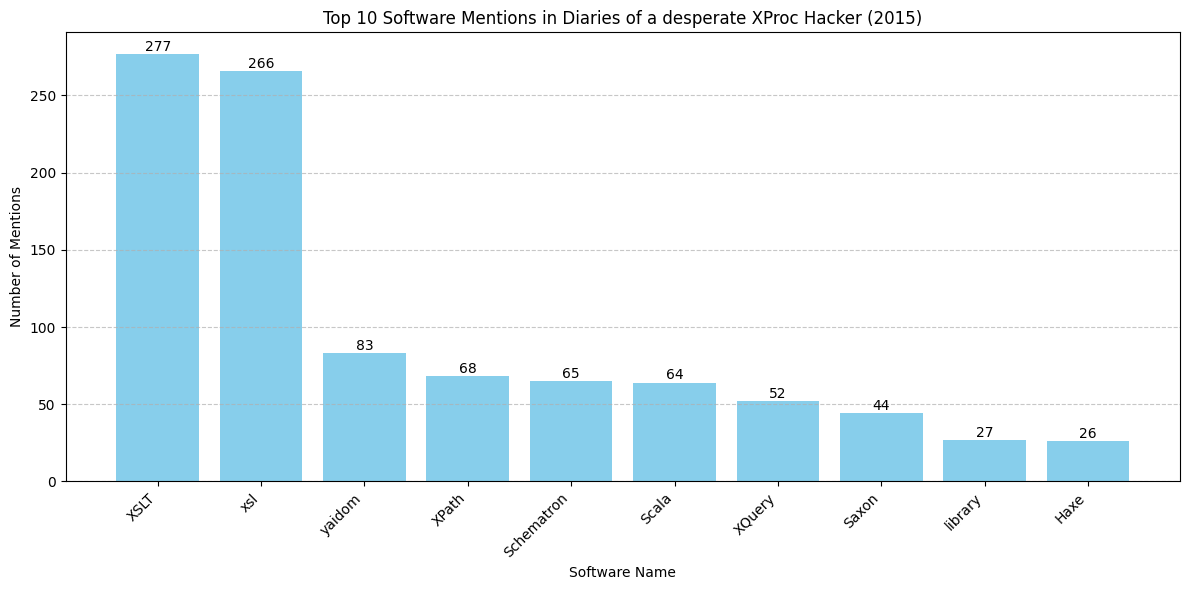

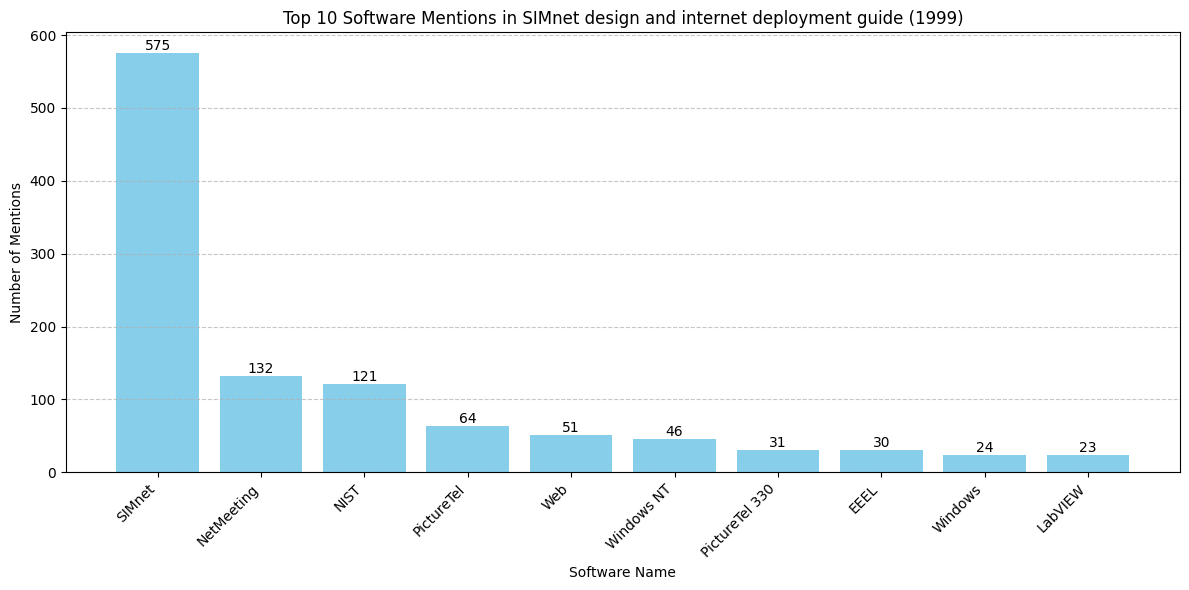

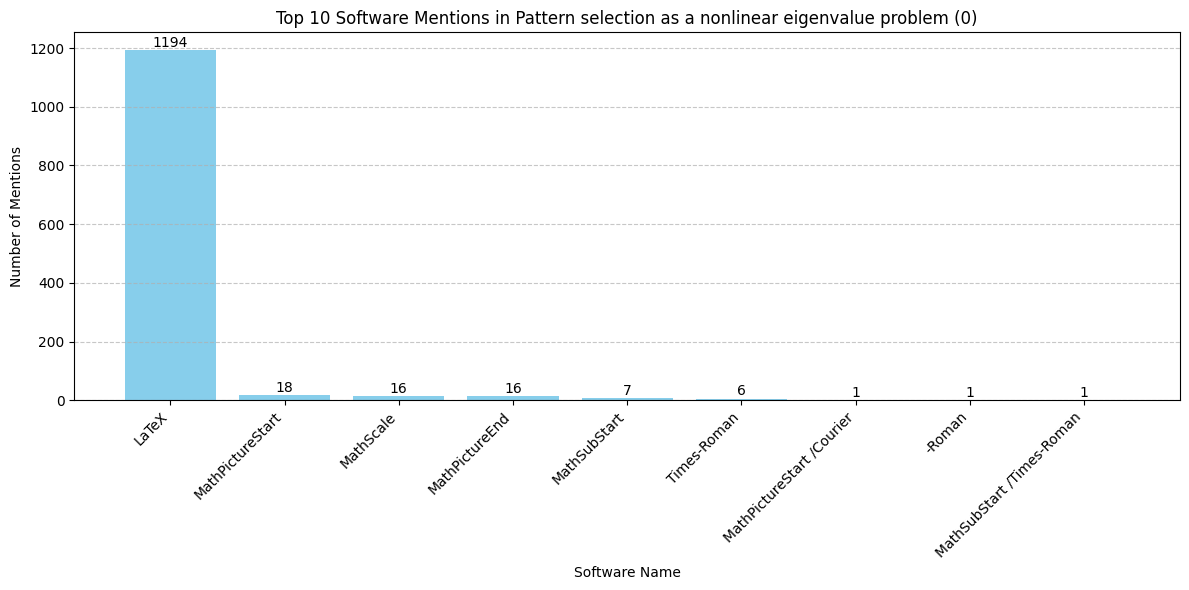

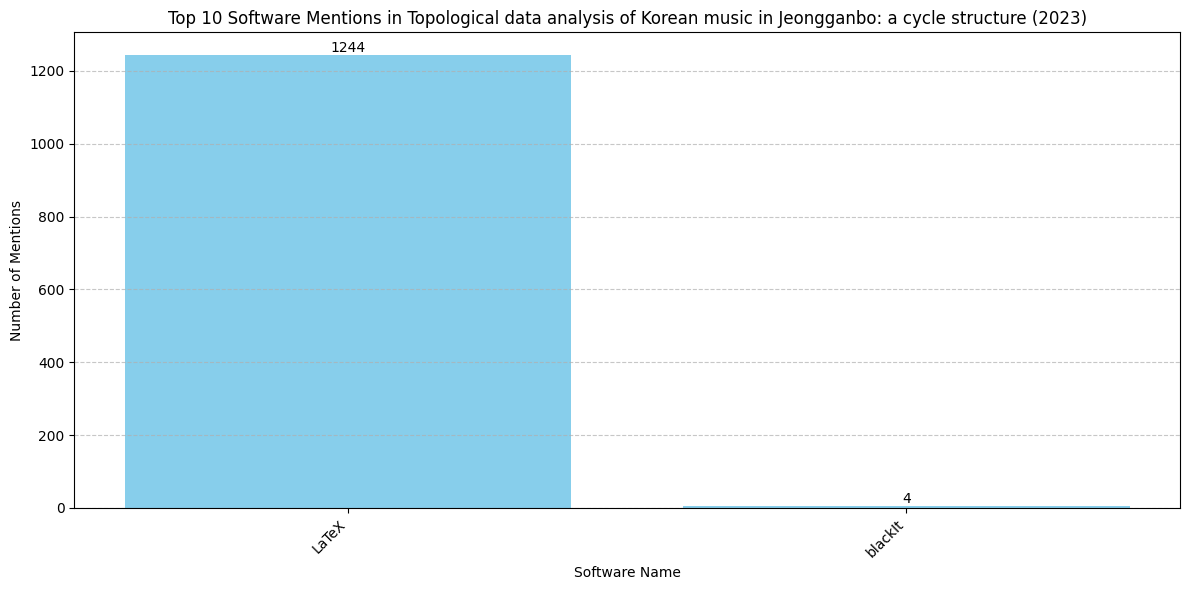

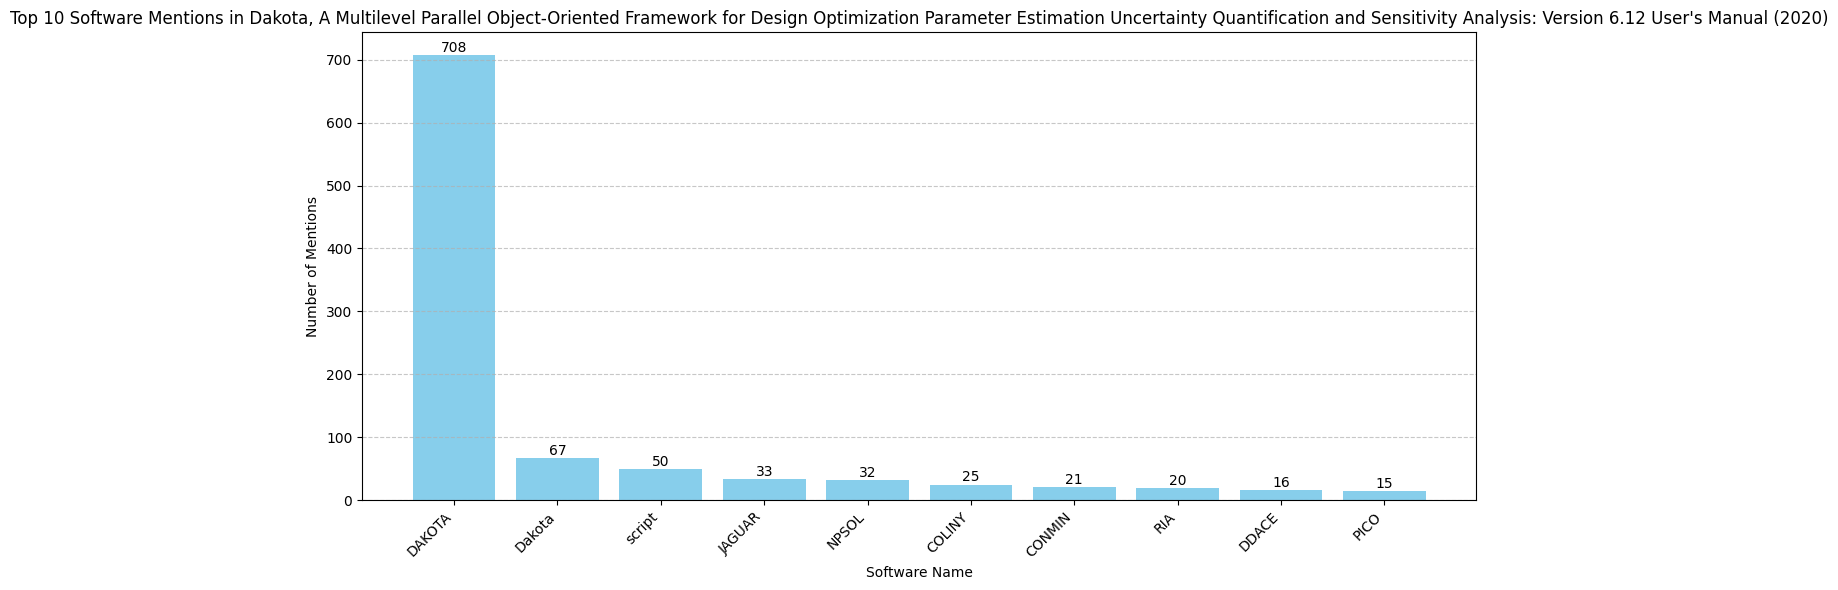

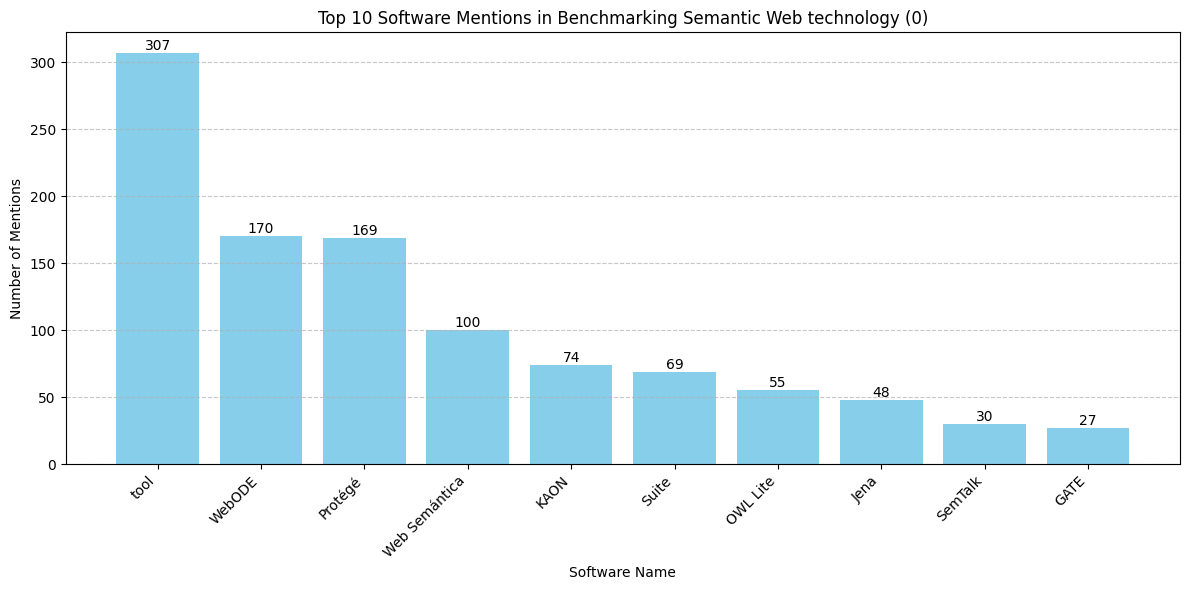

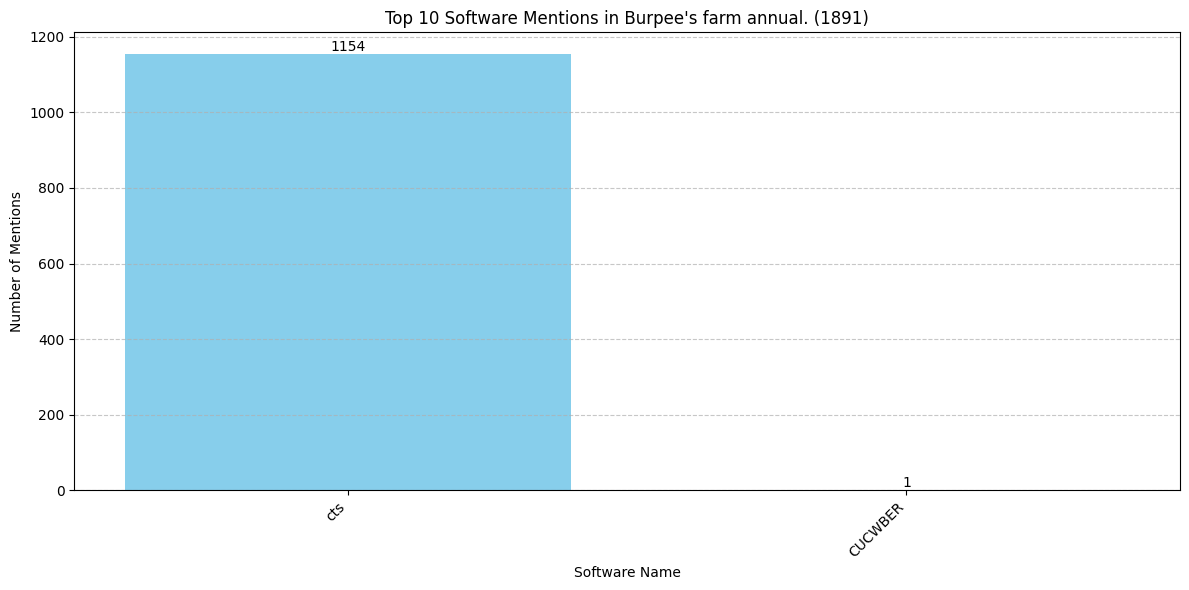

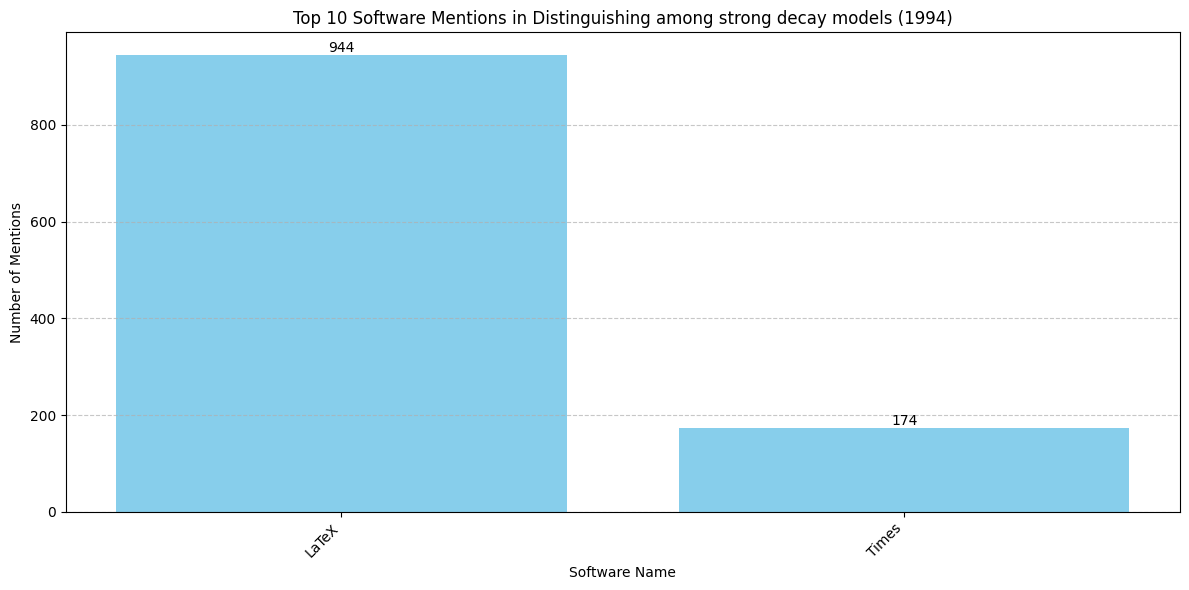

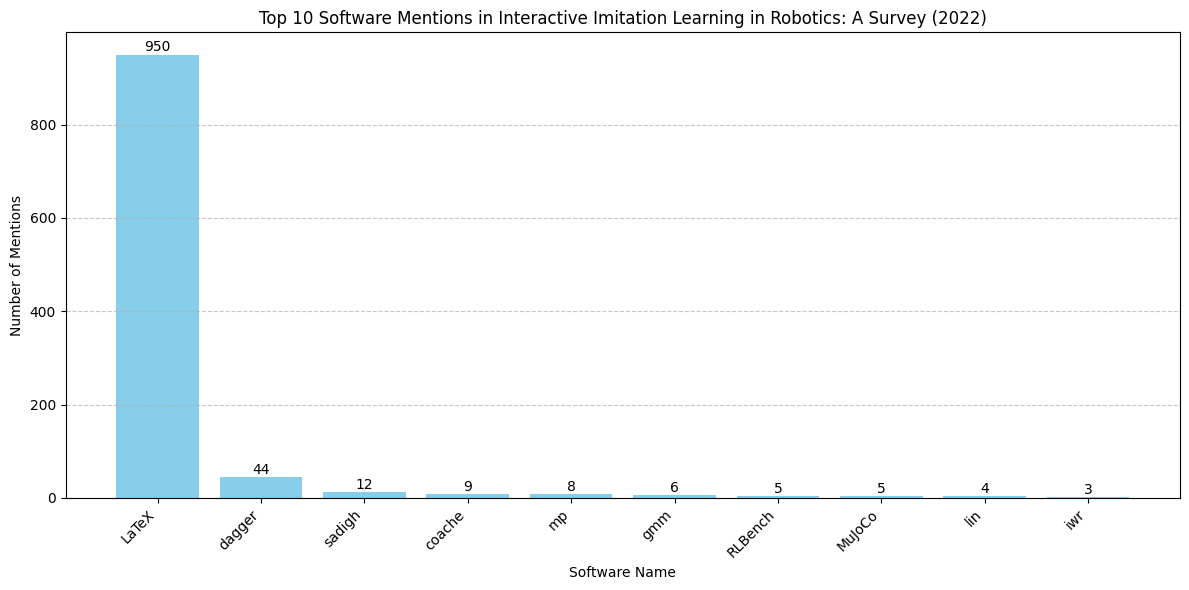

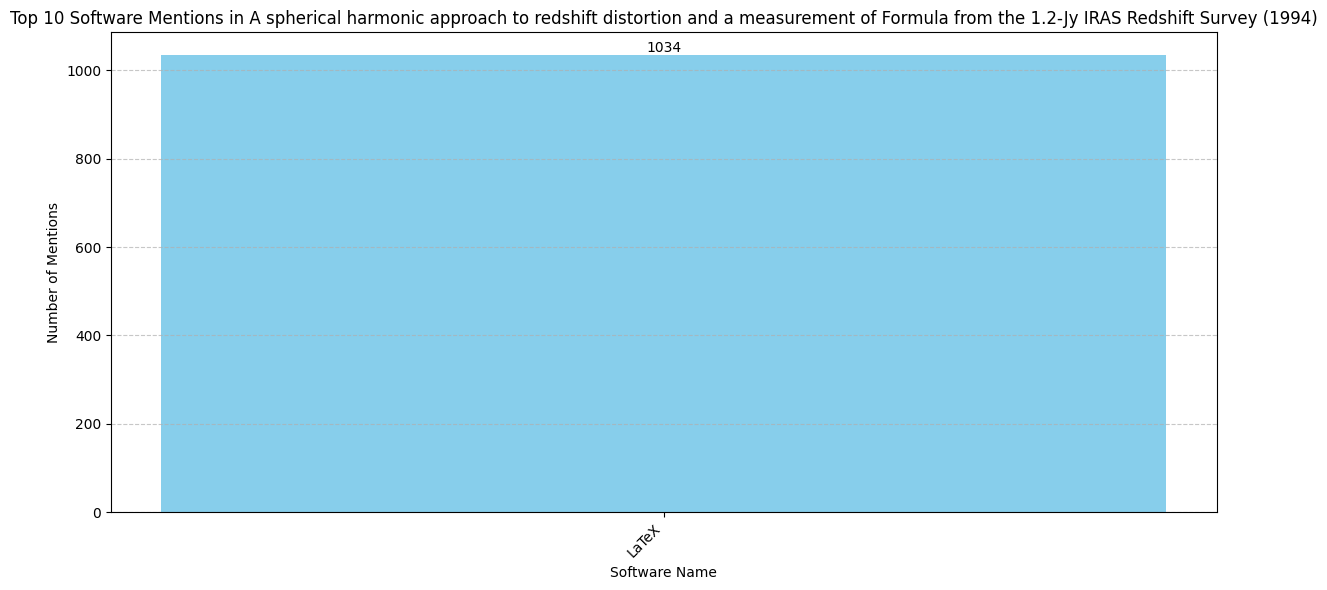

In [74]:
# Top 20 papers by total mention count
top20_paper_ids = (
    mentions_df.groupby('paper_id')
    .size()
    .sort_values(ascending=False)
    .head(20)
    .index
)

bad_paper_id = 10830805

for pid in top20_paper_ids:
    if pid == bad_paper_id:
        # temporary override: no full title
        plot_software_mentions_for_paper(pid, top_n=10)
        plt.title(f"Top Software Mentions in Paper {pid}")  # overwrite long title
        plt.tight_layout()
        plt.show()
    else:
        plot_software_mentions_for_paper(pid, top_n=10)
        plt.show()